## Data understanding:  
They are three different viewing directions (planes) of the MRI scan.  
A brain MRI is a 3D volume, and doctors can slice/view it from different angles.  
### The 3 MRI Planes
1) Axial Plane  
This is like slicing the brain horizontally from top to bottom.  
You look at the brain as if you are standing above the patient looking downward.
2) Coronal Plane  
This slices the brain from front to back.  
You view the patient face-to-face.
3) Sagittal Plane  
This slices the brain from left to right.  
You see the side profile of the brain.

Why Use Multiple Planes?
A tumor may be:  
    1.clearly visible in axial view  
    2.partially hidden in coronal  
    3.shaped better in sagittal  
    
Different planes reveal different spatial information.  
This is extremely important in medical imaging because tumors are 3D structures.  

#### Editing the yaml file, and put it under /kaggle/working

In [1]:
from pathlib import Path

original_yaml = Path(
    "/kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class/axial_t1wce_2_class.yaml"
)

new_yaml = Path("/kaggle/working/axial_t1wce_2_class.yaml")

content = original_yaml.read_text()

content = content.replace(
    "path: ../input/brain-tumor-object-detection-datasets/coronal_t1wce_2_class",
    "path: /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class"
)

lines = content.splitlines()
lines[0] = "path: /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class"

new_yaml.write_text("\n".join(lines))

print("Saved cleaned YAML to:", new_yaml)

Saved cleaned YAML to: /kaggle/working/axial_t1wce_2_class.yaml


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.9 MB/s eta 0:00:00a 0:00:01


Test training for only one epoch:

### Notes For yolo commands:
1. model  
model=yolov8n.pt (خفيف وسريع)

2. data  
data=data.yaml المسارات اللي هتشغلني  

3. epochs  
epochs=100

4. imgsz  حجم الصورة 
imgsz=640   هيقطع كله للحجم دا عشان يوحدها  

5. batch  بيتعمل تلقائي عشان يراعي المعالج  
batch=16  بس هنا كدا كدا كارت شاشة مش مشكلة  

6. project   مكان الحفظ  
project=runs/detect

7. name:  اسم الخرج  
name = axial  

In [ ]:
!yolo train data=/kaggle/working/axial_t1wce_2_class.yaml model=yolo11s.pt epochs=1 imgsz=640

Training for 100 epochs:

In [3]:
!yolo train data=/kaggle/working/axial_t1wce_2_class.yaml model=yolo11s.pt epochs=100 imgsz=640  project=/kaggle/working/runs name=axial

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/axial_t1wce_2_class.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, 

#### Validation:

In [4]:
!yolo val model=/kaggle/working/runs/axial/weights/best.pt data=/kaggle/working/axial_t1wce_2_class.yaml imgsz=640  project=/kaggle/working/runs/axial name=val

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 15.8±2.9 MB/s, size: 6.7 KB)
val: Scanning /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class/labels/test... 75 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 75/75 732.1it/s 0.1s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.9it/s 1.7s0.5s
                   all         75         81      0.878      0.852      0.909      0.632
              negative         75         81      0.878      0.852      0.909      0.632
Speed: 4.1ms preprocess, 10.3ms inference, 0.0ms loss, 1.8ms postprocess pe

#### Inference:

In [5]:
!yolo predict model=/kaggle/working/runs/axial/weights/best.pt source=/kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class/images/test imgsz=640  project=/kaggle/working/runs/axial name=predict


Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/75 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class/images/test/00018_101.jpg: 640x640 1 negative, 15.6ms
image 2/75 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class/images/test/00018_109.jpg: 640x640 1 negative, 15.5ms
image 3/75 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class/images/test/00018_111.jpg: 640x640 1 negative, 15.5ms
image 4/75 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class/images/test/00018_117.jpg: 640x640 1 negative, 15.5ms
image 5/75 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class/images/test/00018_121.jpg: 640x640 1 negative, 15.5ms
image 6/75 /kaggle/input/dataset

#### inference sample:

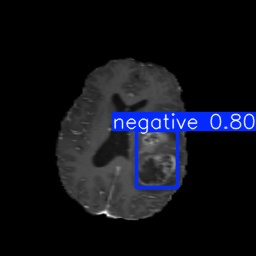

In [6]:
from IPython.display import Image, display
import os

pred_dir = "/kaggle/working/runs/axial/predict"
files = os.listdir(pred_dir)

# Show first predicted image
display(Image(filename=os.path.join(pred_dir, files[5])))

In [7]:
from pathlib import Path

original_yaml = Path(
    "/kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class/coronal_t1wce_2_class.yaml"
)

new_yaml = Path("/kaggle/working/coronal_t1wce_2_class.yaml")

content = original_yaml.read_text()

content = content.replace(
    "path: ../input/brain-tumor-object-detection-datasets/coronal_t1wce_2_class",
    "path: /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class"
)

lines = content.splitlines()
lines[0] = "path: /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class"

new_yaml.write_text("\n".join(lines))

print("Saved cleaned YAML to:", new_yaml)

Saved cleaned YAML to: /kaggle/working/coronal_t1wce_2_class.yaml


In [8]:
from pathlib import Path

original_yaml = Path(
    "/kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class/sagittal_t1wce_2_class.yaml"
)

new_yaml = Path("/kaggle/working/sagittal_t1wce_2_class.yaml")

content = original_yaml.read_text()

content = content.replace(
    "path: ../input/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class",
    "path: /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class"
)

lines = content.splitlines()
lines[0] = "path: /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class"

new_yaml.write_text("\n".join(lines))

print("Saved cleaned YAML to:", new_yaml)

Saved cleaned YAML to: /kaggle/working/sagittal_t1wce_2_class.yaml


In [9]:
!yolo train data=/kaggle/working/coronal_t1wce_2_class.yaml model=yolo11s.pt epochs=100 imgsz=640 project=/kaggle/working/runs name=coronal

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/coronal_t1wce_2_class.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=coronal, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

In [11]:
!yolo val model=/kaggle/working/runs/coronal/weights/best.pt data=/kaggle/working/coronal_t1wce_2_class.yaml imgsz=640 project=/kaggle/working/runs/coronal name=val

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 18.5±12.6 MB/s, size: 12.5 KB)
val: Scanning /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class/labels/test... 78 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 737.3it/s 0.1s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.9it/s 1.7s0.5s
                   all         78         83      0.553      0.788      0.649      0.474
              negative         32         34      0.481      0.824       0.64       0.49
              positive         46         49      0.626      0.752   

In [12]:
!yolo predict model=/kaggle/working/runs/coronal/weights/best.pt  source=/kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class/images/test imgsz=640 project=/kaggle/working/runs/coronal name=predict

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/78 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class/images/test/13.jpg: 640x640 1 positive, 13.1ms
image 2/78 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class/images/test/15.jpg: 640x640 1 negative, 14.6ms
image 3/78 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class/images/test/17.jpg: 640x640 1 negative, 14.5ms
image 4/78 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class/images/test/19.jpg: 640x640 1 negative, 1 positive, 14.5ms
image 5/78 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class/images/test/20.jpg: 640x640 1 negative, 14.6ms
image 6/78 /kaggle/input/datasets/davidbrober

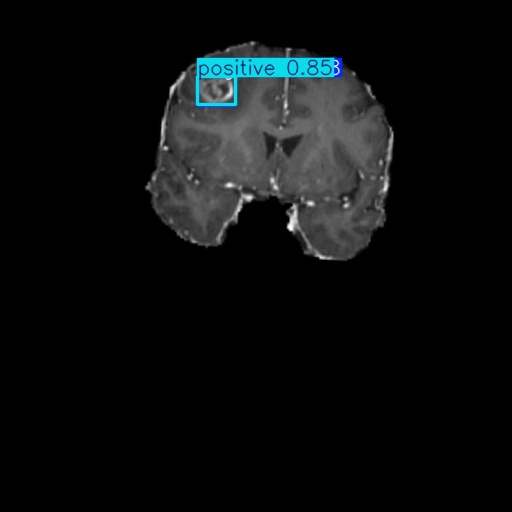

In [13]:
from IPython.display import Image, display
import os

pred_dir = "/kaggle/working/runs/coronal/predict"
files = os.listdir(pred_dir)

display(Image(filename=os.path.join(pred_dir, files[5])))

In [14]:
!yolo train data=/kaggle/working/sagittal_t1wce_2_class.yaml model=yolo11s.pt epochs=100 imgsz=640  project=/kaggle/working/runs name=sagittal

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/sagittal_t1wce_2_class.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sagittal, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

In [16]:
!yolo val model=/kaggle/working/runs/sagittal/weights/best.pt data=/kaggle/working/sagittal_t1wce_2_class.yaml imgsz=640 project=/kaggle/working/runs/sagittal name=val

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 34.5±4.6 MB/s, size: 16.4 KB)
val: Scanning /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class/labels/test... 70 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70 766.1it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.0it/s 1.7s0.5s
                   all         70         77      0.411       0.77      0.491      0.348
              negative         35         39      0.431      0.776      0.425      0.267
              positive         35         38       0.39      0.763      

In [17]:
!yolo predict model=/kaggle/working/runs/sagittal/weights/best.pt source=/kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class/images/test imgsz=640 project=/kaggle/working/runs/sagittal name=predict


Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/70 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class/images/test/00000_102.jpg: 640x640 1 negative, 1 positive, 15.6ms
image 2/70 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class/images/test/00000_121.jpg: 640x640 1 negative, 1 positive, 15.5ms
image 3/70 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class/images/test/00000_140.jpg: 640x640 1 negative, 1 positive, 15.5ms
image 4/70 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class/images/test/00000_159.jpg: 640x640 1 negative, 4 positives, 15.5ms
image 5/70 /kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class/images/test/00002_110.

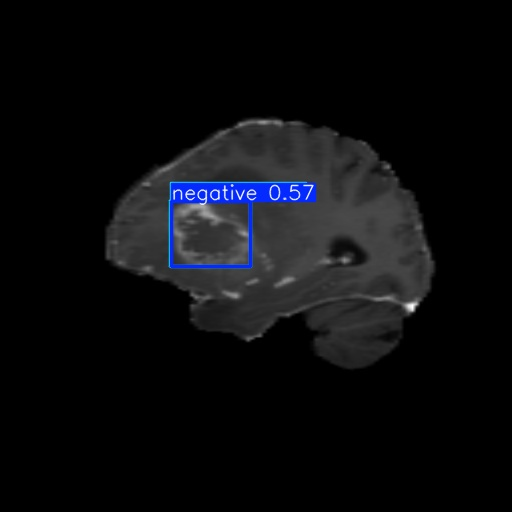

In [18]:
from IPython.display import Image, display
import os

pred_dir = "/kaggle/working/runs/sagittal/predict"
files = os.listdir(pred_dir)

display(Image(filename=os.path.join(pred_dir, files[5])))

## Ensembling the three models (planes/slices)

In [19]:
from ultralytics import YOLO


model_axial = YOLO("/kaggle/working/runs/axial/weights/best.pt")
model_coronal = YOLO("/kaggle/working/runs/coronal/weights/best.pt")
model_sagittal = YOLO("/kaggle/working/runs/sagittal/weights/best.pt")

In [20]:
weights = {
    "axial": 0.5,
    "coronal": 0.3,
    "sagittal": 0.2
}

In [21]:
def ensemble_predict(image_path, conf_thres=0.25):

    r1 = model_axial.predict(image_path, conf=conf_thres, verbose=False)[0]
    r2 = model_coronal.predict(image_path, conf=conf_thres, verbose=False)[0]
    r3 = model_sagittal.predict(image_path, conf=conf_thres, verbose=False)[0]

    # Extract best confidence per model (if no detection → 0)
    def get_conf(result):
        if len(result.boxes) == 0:
            return 0.0
        return float(result.boxes.conf.max())

    p_axial = get_conf(r1)
    p_coronal = get_conf(r2)
    p_sagittal = get_conf(r3)

    # Weighted ensemble
    final_score = (
        weights["axial"] * p_axial +
        weights["coronal"] * p_coronal +
        weights["sagittal"] * p_sagittal
    )

    return {
        "axial": p_axial,
        "coronal": p_coronal,
        "sagittal": p_sagittal,
        "final_score": final_score,
        "prediction": "positive" if final_score > 0.5 else "negative"
    }

In [22]:
image_path = "/kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class/images/test/00022_81.jpg"

result = ensemble_predict(image_path)

print(result)

{'axial': 0.7591927647590637, 'coronal': 0.8849945664405823, 'sagittal': 0.3161487877368927, 'final_score': 0.7083245098590851, 'prediction': 'positive'}


In [23]:
# For axial test images:
import os

test_dir = "/kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/axial_t1wce_2_class/images/test"

results = []

for img in os.listdir(test_dir):
    path = os.path.join(test_dir, img)
    res = ensemble_predict(path)
    results.append((img, res["prediction"], res["final_score"]))

results[:5]

[('00045_136.jpg', 'negative', 0.0),
 ('00072_77.jpg', 'positive', 0.7836064219474792),
 ('00088_150.jpg', 'positive', 0.6604332387447357),
 ('00053_235.jpg', 'positive', 0.8223032236099244),
 ('00018_134.jpg', 'negative', 0.3026266664266586)]

In [24]:
# For coronal test images:
import os

test_dir = "/kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/coronal_t1wce_2_class/images/test"

results_coronal = []

for img in os.listdir(test_dir):
    path = os.path.join(test_dir, img)
    res = ensemble_predict(path)
    results_coronal.append((img, res["prediction"], res["final_score"]))

results_coronal[:5]

[('45.jpg', 'positive', 0.7368530869483948),
 ('56.jpg', 'positive', 0.6993688106536865),
 ('20.jpg', 'positive', 0.7351499676704406),
 ('58.jpg', 'positive', 0.7264756798744202),
 ('53 (3).jpg', 'positive', 0.7516264915466309)]

In [25]:
# For sagittal test images:
import os

test_dir = "/kaggle/input/datasets/davidbroberts/brain-tumor-object-detection-datasets/sagittal_t1wce_2_class/images/test"

results_sagittal = []

for img in os.listdir(test_dir):
    path = os.path.join(test_dir, img)
    res = ensemble_predict(path)
    results_sagittal.append((img, res["prediction"], res["final_score"]))

results_sagittal[:5]

[('00006_210.jpg', 'positive', 0.7886727631092072),
 ('00053_85.jpg', 'positive', 0.667404055595398),
 ('00049_102.jpg', 'positive', 0.7750822186470031),
 ('00003_173.jpg', 'positive', 0.8558347642421722),
 ('00030_215.jpg', 'positive', 0.6896689713001252)]